In [1]:

import numpy as np
import geopandas as gpd
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

C:\Users\x12la\AppData\Local\Temp\ipykernel_33000\1427134174.py:2: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


In [14]:
cmap_shp = gpd.read_file(r"C:\Users\x12la\Desktop\Scripts\CMAP_cty.shp").to_crs("EPSG:4326")
cmap_boundary = cmap_shp.dissolve()

allroads = gpd.read_file("../tl_2019_17_prisecroads.shp").to_crs("EPSG:4326")
allroads_cmap = gpd.clip(allroads,cmap_boundary)

In [9]:
# Separate road classes
cmap_roads_I = allroads_cmap.loc[allroads_cmap["RTTYP"] == "I"].copy()
cmap_roads_S = allroads_cmap.loc[allroads_cmap["RTTYP"] == "S"].copy()
major_interstates = [55, 57, 80, 88, 90, 94, 294, 355]

In [3]:
d01 = Dataset(r"C:\Users\x12la\Desktop\Scripts\wrfout_d01_2023-10-01_00_00_00")

lat1 = np.array(d01["XLAT"][0])
lon1 = np.array(d01["XLONG"][0])

outlinelon1 = np.concatenate([
    lon1[0, :],
    lon1[1:, -1],
    lon1[-1, -2::-1],
    lon1[-2:0:-1, 0],
    [lon1[0, 0]]])

outlinelat1 = np.concatenate([
    lat1[0, :],
    lat1[1:, -1],
    lat1[-1, -2::-1],
    lat1[-2:0:-1, 0],
    [lat1[0, 0]]])

In [4]:
d02 = Dataset(r"C:\Users\x12la\Desktop\Scripts\lat_lon_chicago_d02.nc")

lat2 = d02["LAT"][0][0].data
lon2 = d02["LON"][0][0].data

outlinelon2 = np.concatenate([
    lon2[0, :],
    lon2[1:, -1],
    lon2[-1, -2::-1],
    lon2[-2:0:-1, 0],
    [lon2[0, 0]]])

outlinelat2 = np.concatenate([
    lat2[0, :],
    lat2[1:, -1],
    lat2[-1, -2::-1],
    lat2[-2:0:-1, 0],
    [lat2[0, 0]]])

In [5]:
d03 = Dataset(r"C:\Users\x12la\Desktop\latlon_ChicagoLADCO_d03.nc")

lat3 = np.array(d03["lat"])
lon3 = np.array(d03["lon"])

outlinelon3 = np.concatenate([
    lon3[0, :],
    lon3[1:, -1],
    lon3[-1, -2::-1],
    lon3[-2:0:-1, 0],
    [lon3[0, 0]]])

outlinelat3 = np.concatenate([
    lat3[0, :],
    lat3[1:, -1],
    lat3[-1, -2::-1],
    lat3[-2:0:-1, 0],
    [lat3[0, 0]]])

In [16]:
def add_county_labels(
    ax,
    counties,
    name_column="NAME",
    fontsize=7,
    color="#555555"
):
    for _, row in counties.iterrows():

        geom = row.geometry

        if geom is None or geom.is_empty:
            continue

        point = geom.representative_point()

        ax.text(
            point.x,
            point.y + 0.02,
            row[name_column],
            fontsize=fontsize,
            color=color,
            fontweight="normal",
            ha="center",
            va="center",
            alpha=0.85,
            zorder=40,
            path_effects=[
                pe.Stroke(
                    linewidth=1.5,
                    foreground="white"
                ),
                pe.Normal(),
            ],
        )

In [17]:
def add_interstate_labels(
    ax,
    roads,
    interstate_numbers=None,
    fontsize=6,
    label_every=3,
    min_segment_length=0.03
):

    if interstate_numbers is None:
        interstate_numbers = [
            55, 57, 80, 88, 90, 94, 294, 355
        ]

    # Try common Census/TIGER route-number columns
    route_col = None

    for candidate in [
        "RTTYP",
        "FULLNAME",
        "FULLNAME_1",
        "LINEARID"
    ]:
        if candidate in roads.columns:
            pass

    # Interstate numbers are most reliably obtained from FULLNAME
    if "FULLNAME" not in roads.columns:
        return

    interstate_numbers = [
        str(x) for x in interstate_numbers
    ]

    for interstate in interstate_numbers:

        subset = roads[
            roads["FULLNAME"]
            .astype(str)
            .str.contains(
                rf"\bI[- ]?{interstate}\b",
                case=False,
                regex=True,
                na=False
            )
        ]

        if subset.empty:
            continue

        # Sort by geometry length so the longer road segments
        # are more likely to receive useful labels.
        subset = subset.copy()
        subset["_length"] = subset.geometry.length
        subset = subset.sort_values(
            "_length",
            ascending=False
        )

        counter = 0

        for _, row in subset.iterrows():

            geom = row.geometry

            if geom is None or geom.is_empty:
                continue

            if geom.length < min_segment_length:
                continue

            if counter % label_every != 0:
                counter += 1
                continue

            try:
                point = geom.interpolate(
                    0.5,
                    normalized=True
                )
            except Exception:
                counter += 1
                continue

            ax.text(
                point.x,
                point.y,
                f"I-{interstate}",
                fontsize=fontsize,
                fontweight="bold",
                ha="center",
                va="center",
                color="black",
                zorder=50,
                path_effects=[
                    pe.Stroke(
                        linewidth=2,
                        foreground="white"
                    ),
                    pe.Normal(),
                ],
            )

            counter += 1

In [18]:
def add_scalebar(
    ax,
    length_km=1000,
    location=(0.85, 0.07),
    linewidth=5
):

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    lon_start = x0 + (x1 - x0) * location[0]
    lat_start = y0 + (y1 - y0) * location[1]

    km_per_deg_lon = (
        111.32 *
        np.cos(np.deg2rad(lat_start))
    )

    length_deg = length_km / km_per_deg_lon

    lon_end = lon_start + length_deg

    ax.plot(
        [lon_start, lon_end],
        [lat_start, lat_start],
        color="black",
        linewidth=linewidth,
        transform=ccrs.PlateCarree(),
        zorder=30
    )

    ax.text(
        (lon_start + lon_end) / 2,
        lat_start + 0.55,
        f"{length_km:,} km",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        transform=ccrs.PlateCarree(),
        zorder=31
    )


In [6]:
# def add_scalebar(ax, length_km=1000, location=(0.72, 0.07), linewidth=5):
#     x0, x1 = ax.get_xlim()
#     y0, y1 = ax.get_ylim()

#     lon_start = x0 + (x1 - x0) * location[0]
#     lat_start = y0 + (y1 - y0) * location[1]

#     km_per_deg_lon = 111.32 * np.cos(np.deg2rad(lat_start))
#     length_deg = length_km / km_per_deg_lon

#     lon_end = lon_start + length_deg

#     ax.plot(
#         [lon_start, lon_end],
#         [lat_start, lat_start],
#         color="black",
#         linewidth=linewidth,
#         transform=ccrs.PlateCarree(),
#         zorder=30
#     )

#     ax.text(
#         (lon_start + lon_end) / 2,
#         lat_start + 0.55,
#         f"{length_km:,} km",
#         ha="center",
#         va="bottom",
#         fontsize=10,
#         fontweight="bold",
#         transform=ccrs.PlateCarree(),
#         zorder=31
#     )


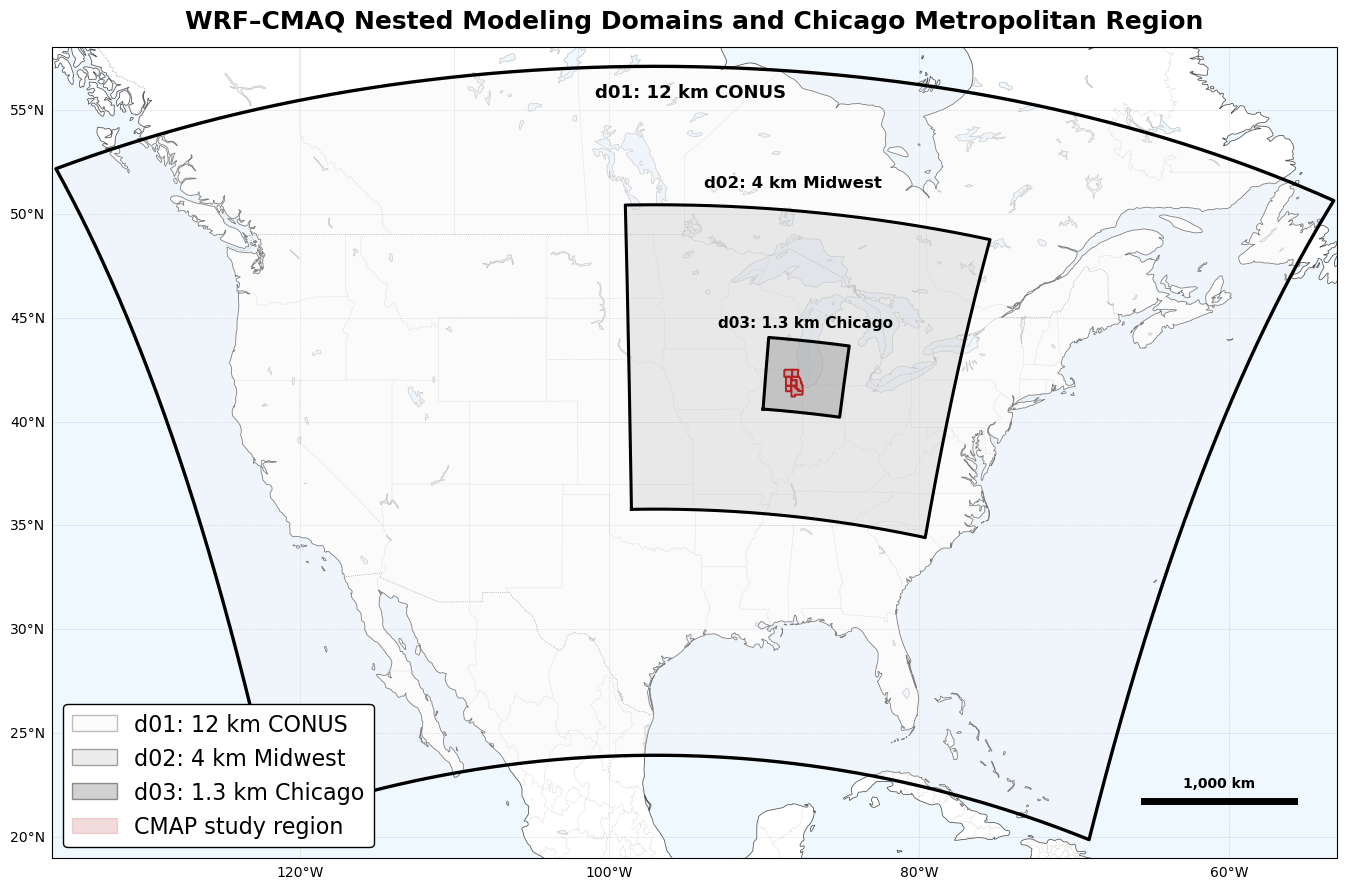

In [19]:
fig = plt.figure(figsize=(15, 9))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.set_extent([-136, -53, 19, 58], crs=ccrs.PlateCarree())

# Base map
states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    edgecolor="gray",
    facecolor="none",
    scale="10m",
    alpha=0.35
)

ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="white", zorder=0)
ax.add_feature(cfeature.LAKES, facecolor="aliceblue", edgecolor="0.75", linewidth=0.5, zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="0.35", zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="0.45", linestyle=":", zorder=2)
ax.add_feature(states, linewidth=0.4, edgecolor="0.65", zorder=2)

# d01
ax.fill(
    outlinelon1, outlinelat1,
    facecolor="0.94",
    edgecolor="none",
    alpha=0.25,
    transform=ccrs.PlateCarree(),
    zorder=3
)

ax.plot(
    outlinelon1, outlinelat1,
    color="black",
    linewidth=2.4,
    transform=ccrs.PlateCarree(),
    zorder=7
)

# d02
ax.fill(
    outlinelon2, outlinelat2,
    facecolor="0.78",
    edgecolor="none",
    alpha=0.35,
    transform=ccrs.PlateCarree(),
    zorder=4
)

ax.plot(
    outlinelon2, outlinelat2,
    color="black",
    linewidth=2.2,
    transform=ccrs.PlateCarree(),
    zorder=8
)

# d03
ax.fill(
    outlinelon3, outlinelat3,
    facecolor="0.55",
    edgecolor="none",
    alpha=0.40,
    transform=ccrs.PlateCarree(),
    zorder=5
)

ax.plot(
    outlinelon3, outlinelat3,
    color="black",
    linewidth=2.2,
    transform=ccrs.PlateCarree(),
    zorder=9
)

# CMAP study region
cmap_shp.plot(
    ax=ax,
    facecolor="firebrick",
    edgecolor="firebrick",
    alpha=0.16,
    linewidth=0.8,
    transform=ccrs.PlateCarree(),
    zorder=10
)

cmap_shp.boundary.plot(
    ax=ax,
    edgecolor="firebrick",
    linewidth=1.4,
    transform=ccrs.PlateCarree(),
    zorder=11
)

# Labels
ax.text(
    np.mean(outlinelon1),
    np.max(outlinelat1) - 0.8,
    "d01: 12 km CONUS",
    ha="center",
    va="top",
    fontsize=13,
    fontweight="bold",
    transform=ccrs.PlateCarree(),
    zorder=12
)

ax.text(
    np.mean(outlinelon2),
    np.max(outlinelat2) + 0.7,
    "d02: 4 km Midwest",
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight="bold",
    transform=ccrs.PlateCarree(),
    zorder=12
)

ax.text(
    np.mean(outlinelon3),
    np.max(outlinelat3) + 0.35,
    "d03: 1.3 km Chicago",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    transform=ccrs.PlateCarree(),
    zorder=12
)

# Gridlines
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.35,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 10}
gl.ylabel_style = {"size": 10}

# Legend
handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="0.94", edgecolor="black", alpha=0.25, label="d01: 12 km CONUS"),
    plt.Rectangle((0, 0), 1, 1, facecolor="0.78", edgecolor="black", alpha=0.35, label="d02: 4 km Midwest"),
    plt.Rectangle((0, 0), 1, 1, facecolor="0.55", edgecolor="black", alpha=0.40, label="d03: 1.3 km Chicago"),
    plt.Rectangle((0, 0), 1, 1, facecolor="firebrick", edgecolor="firebrick", alpha=0.16, label="CMAP study region"),
]

# ax.legend(
#     handles=handles,
#     loc="lower left",
#     frameon=True,
#     #framealpha=1.0,
#     facecolor="white",
#     edgecolor="black",
#     fontsize=16
# )

leg = ax.legend(
    handles=handles,
    loc="lower left",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1.0,
    fontsize=16
)

# Put legend above everything else
leg.set_zorder(1000)

add_scalebar(ax, length_km=1000, location=(0.85, 0.07), linewidth=5)

ax.set_title(
    "WRF–CMAQ Nested Modeling Domains and Chicago Metropolitan Region",
    fontsize=18,
    fontweight="bold",
    pad=14
)


plt.tight_layout()
plt.savefig('NestedDomain.png')
plt.show()

NameError: name 'Rectangle' is not defined

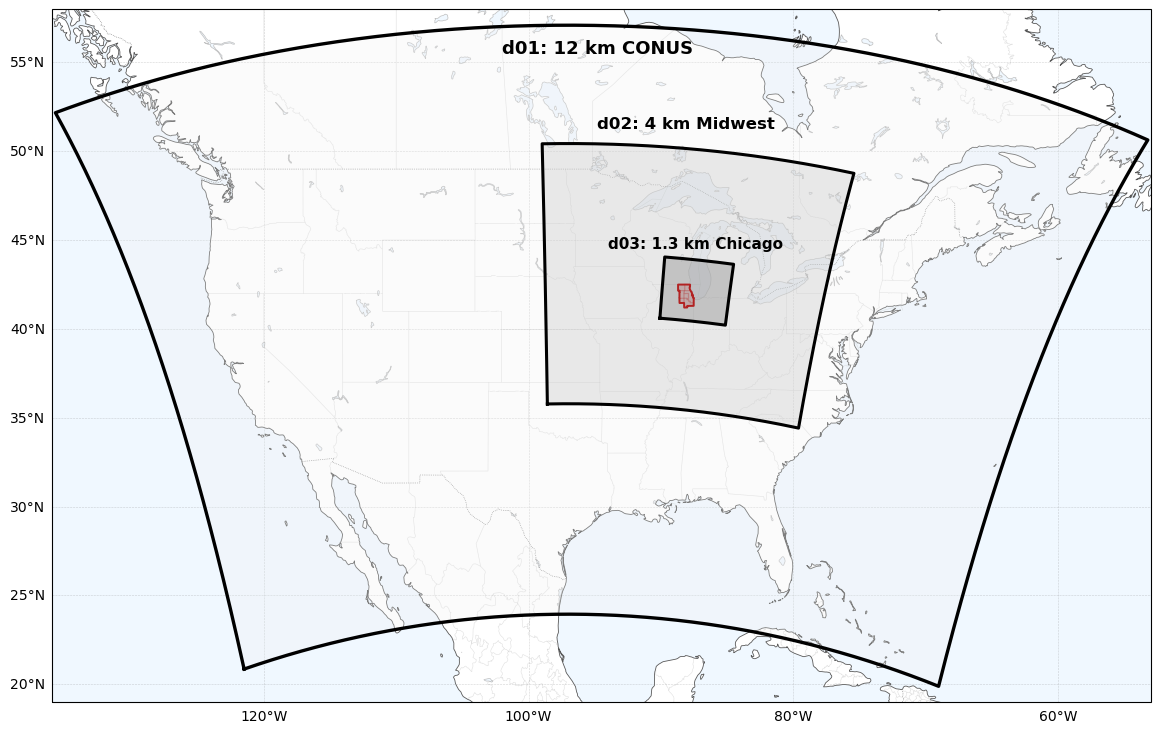

In [20]:
fig = plt.figure(
    figsize=(15, 9)
)

ax = fig.add_subplot(
    1,
    1,
    1,
    projection=ccrs.PlateCarree()
)

ax.set_extent(
    [-136, -53, 19, 58],
    crs=ccrs.PlateCarree()
)


# ============================================================
# 6. MAIN MAP BACKGROUND
# ============================================================

states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    edgecolor="gray",
    facecolor="none",
    scale="10m",
    alpha=0.35
)

ax.add_feature(
    cfeature.OCEAN,
    facecolor="aliceblue",
    zorder=0
)

ax.add_feature(
    cfeature.LAND,
    facecolor="white",
    zorder=0
)

ax.add_feature(
    cfeature.LAKES,
    facecolor="aliceblue",
    edgecolor="0.75",
    linewidth=0.5,
    zorder=1
)

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=0.6,
    edgecolor="0.35",
    zorder=2
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.5,
    edgecolor="0.45",
    linestyle=":",
    zorder=2
)

ax.add_feature(
    states,
    linewidth=0.4,
    edgecolor="0.65",
    zorder=2
)


# ============================================================
# 7. d01
# ============================================================

ax.fill(
    outlinelon1,
    outlinelat1,
    facecolor="0.94",
    edgecolor="none",
    alpha=0.25,
    transform=ccrs.PlateCarree(),
    zorder=3
)

ax.plot(
    outlinelon1,
    outlinelat1,
    color="black",
    linewidth=2.4,
    transform=ccrs.PlateCarree(),
    zorder=7
)


# ============================================================
# 8. d02
# ============================================================

ax.fill(
    outlinelon2,
    outlinelat2,
    facecolor="0.78",
    edgecolor="none",
    alpha=0.35,
    transform=ccrs.PlateCarree(),
    zorder=4
)

ax.plot(
    outlinelon2,
    outlinelat2,
    color="black",
    linewidth=2.2,
    transform=ccrs.PlateCarree(),
    zorder=8
)


# ============================================================
# 9. d03
# ============================================================

ax.fill(
    outlinelon3,
    outlinelat3,
    facecolor="0.55",
    edgecolor="none",
    alpha=0.40,
    transform=ccrs.PlateCarree(),
    zorder=5
)

ax.plot(
    outlinelon3,
    outlinelat3,
    color="black",
    linewidth=2.2,
    transform=ccrs.PlateCarree(),
    zorder=9
)


# ============================================================
# 10. CMAP STUDY REGION ON MAIN MAP
# ============================================================

cmap_shp.plot(
    ax=ax,
    facecolor="firebrick",
    edgecolor="firebrick",
    alpha=0.16,
    linewidth=0.8,
    transform=ccrs.PlateCarree(),
    zorder=10
)

cmap_boundary.boundary.plot(
    ax=ax,
    edgecolor="firebrick",
    linewidth=1.4,
    transform=ccrs.PlateCarree(),
    zorder=11
)


# ============================================================
# 11. DOMAIN LABELS
# ============================================================

ax.text(
    np.mean(outlinelon1),
    np.max(outlinelat1) - 0.8,
    "d01: 12 km CONUS",
    ha="center",
    va="top",
    fontsize=13,
    fontweight="bold",
    transform=ccrs.PlateCarree(),
    zorder=12
)

ax.text(
    np.mean(outlinelon2),
    np.max(outlinelat2) + 0.7,
    "d02: 4 km Midwest",
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight="bold",
    transform=ccrs.PlateCarree(),
    zorder=12
)

ax.text(
    np.mean(outlinelon3),
    np.max(outlinelat3) + 0.35,
    "d03: 1.3 km Chicago",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    transform=ccrs.PlateCarree(),
    zorder=12
)


# ============================================================
# 12. MAIN MAP GRIDLINES
# ============================================================

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.35,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {
    "size": 10
}

gl.ylabel_style = {
    "size": 10
}


# ============================================================
# 13. DOMAIN LEGEND
# ============================================================

handles = [

    Rectangle(
        (0, 0),
        1,
        1,
        facecolor="0.94",
        edgecolor="black",
        alpha=0.25,
        label="d01: 12 km CONUS"
    ),

    Rectangle(
        (0, 0),
        1,
        1,
        facecolor="0.78",
        edgecolor="black",
        alpha=0.35,
        label="d02: 4 km Midwest"
    ),

    Rectangle(
        (0, 0),
        1,
        1,
        facecolor="0.55",
        edgecolor="black",
        alpha=0.40,
        label="d03: 1.3 km Chicago"
    ),

    Rectangle(
        (0, 0),
        1,
        1,
        facecolor="firebrick",
        edgecolor="firebrick",
        alpha=0.16,
        label="CMAP study region"
    ),
]

leg = ax.legend(
    handles=handles,
    loc="lower left",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1.0,
    fontsize=16
)

leg.set_zorder(1000)


# ============================================================
# 14. MAIN MAP SCALE BAR
# ============================================================

add_scalebar(
    ax,
    length_km=1000,
    location=(0.85, 0.07),
    linewidth=5
)


# ============================================================
# 15. CMAP INSET
# ============================================================

# Position = [left, bottom, width, height]
#
# This places it toward the left-center of the main map,
# above the domain legend.
#
inset_ax = fig.add_axes([
    0.145,
    0.315,
    0.245,
    0.36
])

inset_ax.set_facecolor("white")


# ------------------------------------------------------------
# CMAP county fill and boundaries
# ------------------------------------------------------------

cmap_shp.plot(
    ax=inset_ax,
    facecolor="#f7f7f7",
    edgecolor="black",
    linewidth=0.6,
    alpha=1.0,
    zorder=0
)

cmap_shp.boundary.plot(
    ax=inset_ax,
    color="black",
    linewidth=0.55,
    alpha=0.65,
    zorder=5
)

cmap_boundary.boundary.plot(
    ax=inset_ax,
    color="black",
    linewidth=1.25,
    zorder=6
)


# ------------------------------------------------------------
# All roads
# ------------------------------------------------------------

allroads_cmap.plot(
    ax=inset_ax,
    color="lightgrey",
    linewidth=0.20,
    alpha=0.55,
    zorder=1
)


# ------------------------------------------------------------
# State highways
# ------------------------------------------------------------

cmap_roads_S.plot(
    ax=inset_ax,
    color="silver",
    linewidth=0.40,
    alpha=0.85,
    zorder=2
)


# ------------------------------------------------------------
# Interstates
# ------------------------------------------------------------

cmap_roads_I.plot(
    ax=inset_ax,
    color="orange",
    linewidth=1.25,
    alpha=0.95,
    zorder=3
)


# ------------------------------------------------------------
# County labels
# ------------------------------------------------------------

add_county_labels(
    inset_ax,
    cmap_shp,
    fontsize=7,
    color="#555555"
)


# ------------------------------------------------------------
# Interstate labels
# ------------------------------------------------------------

add_interstate_labels(
    inset_ax,
    cmap_roads_I,
    interstate_numbers=major_interstates,
    fontsize=5.5,
    label_every=3,
    min_segment_length=0.03
)


# ------------------------------------------------------------
# Airports
# ------------------------------------------------------------

# O'Hare International Airport
inset_ax.scatter(
    -87.904724,
    41.978611,
    marker="*",
    s=150,
    color="blue",
    edgecolor="black",
    linewidth=0.35,
    zorder=60
)

# Midway Airport
inset_ax.scatter(
    -87.7522,
    41.7868,
    marker="*",
    s=150,
    color="green",
    edgecolor="black",
    linewidth=0.35,
    zorder=60
)


# ------------------------------------------------------------
# Set extent tightly around CMAP
# ------------------------------------------------------------

xmin, ymin, xmax, ymax = cmap_boundary.total_bounds

dx = (xmax - xmin) * 0.045
dy = (ymax - ymin) * 0.045

inset_ax.set_xlim(
    xmin - dx,
    xmax + dx
)

inset_ax.set_ylim(
    ymin - dy,
    ymax + dy
)

inset_ax.set_aspect(
    "equal"
)

inset_ax.set_xticks([])
inset_ax.set_yticks([])


# ------------------------------------------------------------
# Inset frame
# ------------------------------------------------------------

for spine in inset_ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.4)


# ------------------------------------------------------------
# Inset title
# ------------------------------------------------------------

inset_ax.set_title(
    "CMAP Study Region",
    fontsize=10,
    fontweight="bold",
    pad=4
)


# ============================================================
# 16. INSET LEGEND
# ============================================================

road_handles = [

    Line2D(
        [0], [0],
        color="orange",
        lw=2,
        label="Interstate"
    ),

    Line2D(
        [0], [0],
        color="silver",
        lw=2,
        label="State / highway"
    ),

    Line2D(
        [0], [0],
        color="lightgrey",
        lw=2,
        label="Other roads"
    ),

    Line2D(
        [0], [0],
        marker="*",
        linestyle="none",
        markerfacecolor="blue",
        markeredgecolor="black",
        markersize=8,
        label="O'Hare"
    ),

    Line2D(
        [0], [0],
        marker="*",
        linestyle="none",
        markerfacecolor="green",
        markeredgecolor="black",
        markersize=8,
        label="Midway"
    ),
]

inset_legend = inset_ax.legend(
    handles=road_handles,
    loc="lower left",
    fontsize=6.5,
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=0.95,
    borderpad=0.5,
    handlelength=1.6
)

inset_legend.set_zorder(1000)


# ============================================================
# 17. MAIN TITLE
# ============================================================

ax.set_title(
    "WRF–CMAQ Nested Modeling Domains and Chicago Metropolitan Region",
    fontsize=18,
    fontweight="bold",
    pad=14
)


# ============================================================
# 18. SAVE
# ============================================================

# Do NOT use plt.tight_layout() here.
#
# Because the inset was manually positioned with fig.add_axes(),
# tight_layout can shift the main axes without shifting the inset
# in the same way.

plt.savefig(
    "NestedDomain_CMAPInset.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()